In [1]:
library(ComplexHeatmap)
library(dplyr)
library(RColorBrewer)
library(circlize)  
library(dendextend) 
library(NbClust)
library(ggplot2)
library(ggpubr)
library(tidyr)
library(viridis)

Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.3.2”
Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Warning message:
“package ‘dplyr’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects a

In [2]:
load("/vol/projects/yzhang/2000HIV/heatmap/output/heatmap_200hiv_spears_sig_feature_nature.Rdata")

In [2]:
cytokine <- read.csv("/vol/projects/yzhang/2000HIV/cytokine/input/cytokine_filter20percent.csv",row.names=1)
head(cytokine)
dim(cytokine)

protein <- readRDS("/vol/projects/yzhang/2000HIV/protein/input/protein_trans.rds")
head(protein)
head(protein)
dim(protein)

basicPhenos = readRDS("/vol/projects/yzhang/2000HIV/cytokine/input/phenotype_trans.rds")
head(basicPhenos)
dim(basicPhenos)

,pbmc_24h_il1b_cmv,pbmc_24h_il1b_spneu,pbmc_24h_il1b_lps,pbmc_24h_il1b_imq,pbmc_24h_il1b_hivenv,pbmc_24h_il1ra_cmv,pbmc_24h_il1ra_spneu,pbmc_24h_il1ra_lps,pbmc_24h_il1ra_imq,pbmc_24h_il1ra_hivenv,⋯,pbmc_7d_il17_pha,pbmc_7d_il17_spneu,pbmc_7d_il22_candconidia,pbmc_7d_il22_ecoli,pbmc_7d_il22_pha,pbmc_7d_il22_saureus,pbmc_7d_il22_spneu,pbmc_7d_ifng_ecoli,pbmc_7d_ifng_mtb,pbmc_7d_ifng_pha
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EMC001,10000.00,7370.58,2405.67,857.04,398.39,35141.03,50000.00,30764.50,10782.69,26696.89,⋯,248.600,233.750,NA,NA,NA,NA,NA,129.73,185.98,NA
EMC002,2243.47,4462.62,3636.79,134.10,201.65,8479.62,12609.11,4751.90,2260.43,15171.68,⋯,294.985,786.120,NA,NA,NA,NA,NA,114.91,NA,NA
EMC003,265.52,1001.05,571.79,137.41,52.71,5907.60,16053.34,4732.00,3837.38,12713.14,⋯,NA,NA,NA,NA,NA,NA,NA,108.75,5210.15,NA
EMC004,1131.58,1992.97,2539.65,323.54,67.64,7597.27,12693.95,10608.64,3403.42,7885.21,⋯,1012.705,462.670,NA,NA,NA,NA,NA,358.99,12846.40,1025.06
EMC005,1386.23,2745.55,1353.02,192.11,157.81,5062.21,16105.52,4098.42,1695.22,5190.42,⋯,204.125,212.765,NA,NA,NA,NA,NA,289.11,565.66,NA
EMC006,3450.59,5401.58,3182.81,364.28,1333.40,4995.23,5458.92,3534.69,2342.38,10288.46,⋯,539.630,266.615,NA,NA,NA,NA,NA,666.53,26316.05,4796.34


[1] 1793   55

,ADA_Inflammation,ADAM23_Inflammation,ADGRE2_Inflammation,AGER_Inflammation,AGRN_Inflammation,AGRP_Inflammation,AMBN_Inflammation,AMN_Inflammation,ANGPT1_Inflammation,ANGPTL2_Inflammation,⋯,TOP1_Oncology_II,TPBGL_Neurology_II,TPSD1_Neurology_II,TRIM24_Oncology_II,TSPAN8_Oncology_II,USP28_Neurology_II,VSIG10_Oncology_II,VWC2L_Neurology_II,WFDC1_Oncology_II,ZPR1_Neurology_II
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EMC001,0.7790,0.6458,0.6336,-0.1163,0.9304,1.7794,0.0205,-0.0042,2.9810,1.0619,⋯,-3.0757,-0.55765,-0.04655,0.36335,0.7144,0.66245,-0.4931,-0.0029,0.2871,1.39735
EMC002,0.7857,0.7354,0.5094,-0.1915,0.9143,1.4944,0.0301,0.4611,3.3934,1.1801,⋯,1.0739,-0.97725,0.12795,0.37085,1.6285,0.96085,0.4130,-0.5322,0.3947,1.41945
EMC003,1.0680,0.8843,0.6469,-0.2542,0.3536,1.2675,0.0461,0.6872,4.5924,0.5850,⋯,0.6497,-1.10720,0.64670,0.78580,3.6528,1.09060,-0.0119,-1.1839,0.4478,-1.29240
EMC004,1.2890,0.8026,0.0457,0.1829,0.5774,1.0547,0.1545,0.4511,3.0632,0.5104,⋯,-0.8576,-1.82185,0.13655,-0.32505,1.1313,0.65915,-0.6425,-0.2787,-0.1305,-0.65275
EMC005,1.4618,0.2730,-0.4114,-0.3902,0.2315,-0.0840,0.0103,0.1579,3.6901,0.8368,⋯,0.8397,-2.01265,0.19625,0.11985,2.2040,0.73315,0.6302,-0.3740,0.2625,0.20925
EMC006,1.3196,0.9927,0.3348,-0.0561,1.5668,0.9644,0.1760,-0.4015,3.3213,1.5539,⋯,-4.0346,-1.75275,0.67675,-0.48685,1.5548,1.00225,-0.0834,-0.0626,0.5362,-0.30915


[1] 1863 1362

,age,sex,bmi,hiv_duration,season_sin,season_cos,ethnicity,lockdown,covid_vacc,covid,center_EMC,center_ETZ,center_OLV,center_RAD
,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
EMC001,66,1,27.66,8.93,-0.66394765,0.74777905,White,0,0,0,1,0,0,0
EMC002,70,1,26.18,18.17,-0.59725441,0.80205185,White,0,0,0,1,0,0,0
EMC003,58,1,30.37,16.22,-0.59725441,0.80205185,White,0,0,0,1,0,0,0
EMC004,46,1,24.94,15.84,-0.58336949,0.81220690,White,0,0,0,1,0,0,0
EMC005,62,1,25.56,6.63,-0.56931193,0.82212160,Asian,0,0,0,1,0,0,0
EMC006,56,1,29.91,13.12,-0.56931193,0.82212160,White,0,0,0,1,0,0,0


[1] 1895   14

In [3]:
protein_500fg_names <- c(
   "IL18", "CCL25", "MCP_1", "IL_15RA", "CCL3", "IL6", "IL8", "CDCP1",
  "CST5", "Flt3L", "VEGFA", "MCP_2", "OPG", "CCL4", "HGF", "MCP_4",
  "CCL11", "MMP_1", "CCL28", "CXCL10", "CXCL11", "CXCL9", "CXCL1",
  "CXCL5", "CASP_8", "LAP_TGF_beta_1", "CD40", "IL_10RB", "CX3CL1",
  "TRANCE", "IL_12B", "TNFRSF9", "CD5", "TNFB", "CD8A", "SCF", "NT_3"
)
print(protein_500fg_names)
length(protein_500fg_names)

 [1] "IL18"           "CCL25"          "MCP_1"          "IL_15RA"       
 [5] "CCL3"           "IL6"            "IL8"            "CDCP1"         
 [9] "CST5"           "Flt3L"          "VEGFA"          "MCP_2"         
[13] "OPG"            "CCL4"           "HGF"            "MCP_4"         
[17] "CCL11"          "MMP_1"          "CCL28"          "CXCL10"        
[21] "CXCL11"         "CXCL9"          "CXCL1"          "CXCL5"         
[25] "CASP_8"         "LAP_TGF_beta_1" "CD40"           "IL_10RB"       
[29] "CX3CL1"         "TRANCE"         "IL_12B"         "TNFRSF9"       
[33] "CD5"            "TNFB"           "CD8A"           "SCF"           
[37] "NT_3"          


[1] 37

In [4]:
# Prefix of each column name in current protein (part before first "_")
prefix_in_protein <- sub("_.*", "", colnames(protein))

# Prefix of 500FG names (if protein_500fg_names are full names, take prefix first)
prefix_500fg <- sub("_.*", "", protein_500fg_names)

# In 500FG order, find full column names in protein whose prefix matches
full_names_matched <- colnames(protein)[match(prefix_500fg, prefix_in_protein)]

# Drop NA (no match)
full_names_matched <- full_names_matched[!is.na(full_names_matched)]

# Subset original protein by these columns; column names unchanged
protein_subset <- protein[, full_names_matched, drop = FALSE]

# Inspect
head(protein_subset)
dim(protein_subset)

,IL18_Inflammation,CCL25_Inflammation,CCL3_Inflammation,IL6_Inflammation,CDCP1_Neurology,CST5_Neurology,VEGFA_Inflammation,CCL4_Inflammation,HGF_Inflammation,CCL11_Inflammation,CCL28_Inflammation,CXCL10_Inflammation,CXCL11_Neurology,CXCL9_Inflammation,CXCL1_Inflammation,CXCL5_Cardiometabolic,CD40_Inflammation,CD8A_Neurology
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EMC001,0.8581,0.6079,0.3113,0.2725,0.0718,0.1956,1.3919,0.5048,0.9080,0.4188,2.2137,1.1583,2.3351,1.0533,1.6731,3.7548,1.9204,1.3951
EMC002,2.0435,1.1166,1.6065,1.6619,0.9759,0.8469,1.9134,2.0244,1.9506,0.8017,2.8582,1.1965,2.5307,1.3912,1.9580,3.2849,2.2758,1.6291
EMC003,0.9729,1.9677,1.0590,1.6999,0.6712,0.2974,1.1344,1.9501,1.8392,0.6715,3.0325,1.0153,2.8703,1.7194,0.9272,1.8471,1.6490,1.1131
EMC004,2.3110,1.5096,0.4929,2.7524,0.3823,0.3821,1.0187,0.5673,1.1025,0.1186,1.9140,0.7454,1.2129,-0.0983,2.1535,3.9035,1.6252,1.0006
EMC005,1.6281,1.2657,0.9346,0.2311,0.6083,0.3218,1.8123,1.0826,1.2467,0.7569,2.7437,0.6098,3.5455,0.1101,2.1023,3.6042,1.6454,1.0050
EMC006,1.7526,1.3535,0.7264,1.1919,0.7309,0.1886,2.1497,0.6473,1.6809,0.7160,2.8996,1.1545,3.3006,0.6946,2.5330,5.2026,2.6555,2.1459


[1] 1863   18

In [5]:
# Find sample IDs common to all three datasets
common_samples <- intersect(rownames(protein_subset), rownames(basicPhenos))

# Keep only common samples
protein_filtered <- protein_subset[common_samples, , drop = FALSE]
basicPhenos_filtered <- basicPhenos[rownames(basicPhenos) %in% common_samples, , drop = FALSE]
basicPhenos_filtered <- as.data.frame(basicPhenos_filtered)

# Set rownames of basicPhenos_filtered to match common_samples
rownames(basicPhenos_filtered) <- rownames(basicPhenos_filtered)

# Keep only common samples in basicPhenos_filtered
basicPhenos_filtered <- basicPhenos_filtered[common_samples, , drop = FALSE]

# Merge data (keep all features)
merged_data <- data.frame(
  Sample_ID = common_samples,
  Age = basicPhenos_filtered$age,
  protein_filtered
)

# Inspect merged data
head(merged_data)
dim(merged_data)

,Sample_ID,Age,IL18_Inflammation,CCL25_Inflammation,CCL3_Inflammation,IL6_Inflammation,CDCP1_Neurology,CST5_Neurology,VEGFA_Inflammation,CCL4_Inflammation,HGF_Inflammation,CCL11_Inflammation,CCL28_Inflammation,CXCL10_Inflammation,CXCL11_Neurology,CXCL9_Inflammation,CXCL1_Inflammation,CXCL5_Cardiometabolic,CD40_Inflammation,CD8A_Neurology
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EMC001,EMC001,66,0.8581,0.6079,0.3113,0.2725,0.0718,0.1956,1.3919,0.5048,0.9080,0.4188,2.2137,1.1583,2.3351,1.0533,1.6731,3.7548,1.9204,1.3951
EMC002,EMC002,70,2.0435,1.1166,1.6065,1.6619,0.9759,0.8469,1.9134,2.0244,1.9506,0.8017,2.8582,1.1965,2.5307,1.3912,1.9580,3.2849,2.2758,1.6291
EMC003,EMC003,58,0.9729,1.9677,1.0590,1.6999,0.6712,0.2974,1.1344,1.9501,1.8392,0.6715,3.0325,1.0153,2.8703,1.7194,0.9272,1.8471,1.6490,1.1131
EMC004,EMC004,46,2.3110,1.5096,0.4929,2.7524,0.3823,0.3821,1.0187,0.5673,1.1025,0.1186,1.9140,0.7454,1.2129,-0.0983,2.1535,3.9035,1.6252,1.0006
EMC005,EMC005,62,1.6281,1.2657,0.9346,0.2311,0.6083,0.3218,1.8123,1.0826,1.2467,0.7569,2.7437,0.6098,3.5455,0.1101,2.1023,3.6042,1.6454,1.0050
EMC006,EMC006,56,1.7526,1.3535,0.7264,1.1919,0.7309,0.1886,2.1497,0.6473,1.6809,0.7160,2.8996,1.1545,3.3006,0.6946,2.5330,5.2026,2.6555,2.1459


[1] 1849   20

In [6]:
head(merged_data)
dim(merged_data)
write.csv(merged_data,"/vol/projects/yzhang/2000HIV/heatmap/input/cytokine_protein_sig_merged_data_shared_gender.csv")

,Sample_ID,Age,IL18_Inflammation,CCL25_Inflammation,CCL3_Inflammation,IL6_Inflammation,CDCP1_Neurology,CST5_Neurology,VEGFA_Inflammation,CCL4_Inflammation,HGF_Inflammation,CCL11_Inflammation,CCL28_Inflammation,CXCL10_Inflammation,CXCL11_Neurology,CXCL9_Inflammation,CXCL1_Inflammation,CXCL5_Cardiometabolic,CD40_Inflammation,CD8A_Neurology
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EMC001,EMC001,66,0.8581,0.6079,0.3113,0.2725,0.0718,0.1956,1.3919,0.5048,0.9080,0.4188,2.2137,1.1583,2.3351,1.0533,1.6731,3.7548,1.9204,1.3951
EMC002,EMC002,70,2.0435,1.1166,1.6065,1.6619,0.9759,0.8469,1.9134,2.0244,1.9506,0.8017,2.8582,1.1965,2.5307,1.3912,1.9580,3.2849,2.2758,1.6291
EMC003,EMC003,58,0.9729,1.9677,1.0590,1.6999,0.6712,0.2974,1.1344,1.9501,1.8392,0.6715,3.0325,1.0153,2.8703,1.7194,0.9272,1.8471,1.6490,1.1131
EMC004,EMC004,46,2.3110,1.5096,0.4929,2.7524,0.3823,0.3821,1.0187,0.5673,1.1025,0.1186,1.9140,0.7454,1.2129,-0.0983,2.1535,3.9035,1.6252,1.0006
EMC005,EMC005,62,1.6281,1.2657,0.9346,0.2311,0.6083,0.3218,1.8123,1.0826,1.2467,0.7569,2.7437,0.6098,3.5455,0.1101,2.1023,3.6042,1.6454,1.0050
EMC006,EMC006,56,1.7526,1.3535,0.7264,1.1919,0.7309,0.1886,2.1497,0.6473,1.6809,0.7160,2.8996,1.1545,3.3006,0.6946,2.5330,5.2026,2.6555,2.1459


[1] 1849   20

In [13]:
sum(is.na(merged_data))

[1] 0

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(everything(), median, na.rm = TRUE)`.
ℹ In group 1: `Age = 19`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


agg_record_2048374503 
                    2

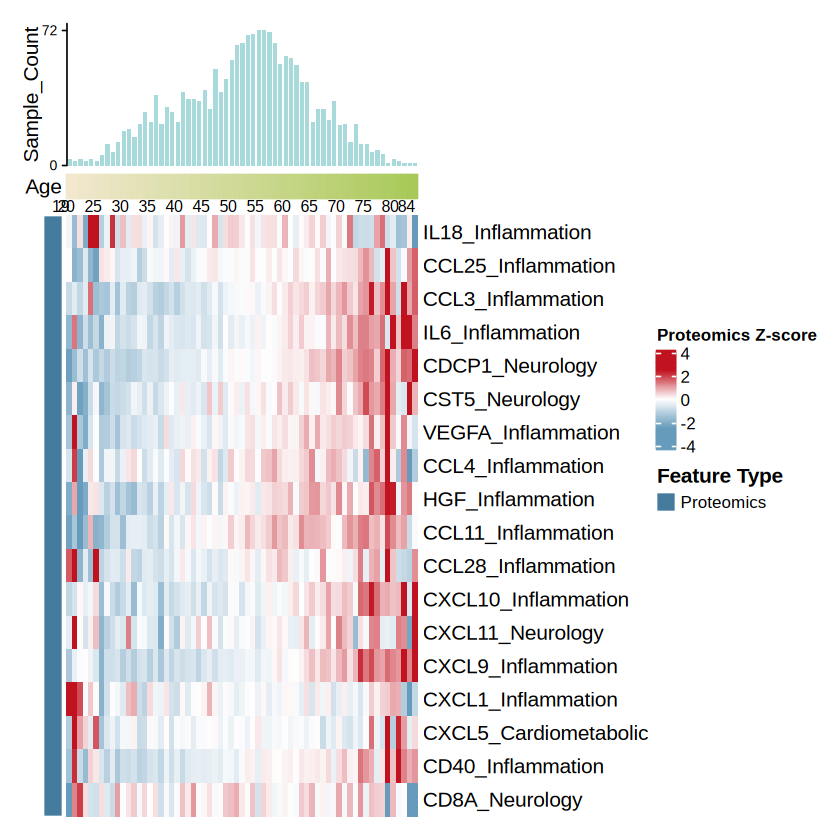

In [7]:
##same feature and same order
heatmap_data <- merged_data[, !(colnames(merged_data) %in% c("Sample_ID", "Age"))]

# 1. **Ensure Age is sorted in order**
sorted_indices <- order(merged_data$Age, na.last = FALSE)
heatmap_data_sorted <- heatmap_data[sorted_indices, , drop = FALSE]
age_sorted <- merged_data$Age[sorted_indices]

# 2. **Remove NA and synchronize Age**
valid_rows <- complete.cases(heatmap_data_sorted)  # Ensure all rows have no NA
heatmap_data_sorted <- heatmap_data_sorted[valid_rows, , drop = FALSE]
age_sorted <- age_sorted[valid_rows]

# 3. **Convert DataFrame and merge Age**
heatmap_data_sorted <- as.data.frame(heatmap_data_sorted)
heatmap_data_sorted$Age <- age_sorted

# 4. **Group by Age and calculate median**
heatmap_data_grouped <- heatmap_data_sorted %>%
  group_by(Age) %>%
  summarise(across(everything(), median, na.rm = TRUE)) %>%
  ungroup() %>%
  arrange(Age)  # Ensure Age is still in ascending order

# Separate data BEFORE transposin
age_sorted <- heatmap_data_grouped$Age
heatmap_data_grouped_matrix <- as.matrix(select(heatmap_data_grouped, -Age))

# 7. **Create Feature Type vector** - All features are Protein type
# feature_types <- rep("Protein", ncol(heatmap_data_grouped))
# # 5. **Separate data by Feature Type BEFORE transposing**
# protein_cols <- which(feature_types == "Protein")

# protein_data_original <- heatmap_data_grouped_matrix[, protein_cols, drop = FALSE]

# # Transpose each data type separately
# protein_data <- t(protein_data_original)
protein_data_original <- heatmap_data_grouped_matrix
protein_data <- t(protein_data_original)

# 6. **Calculate sample counts for each Age group**
age_counts <- as.data.frame(table(merged_data$Age))  # Count original Age occurrences
colnames(age_counts) <- c("Age", "Count")  # Ensure clear column names
age_counts$Age <- as.numeric(as.character(age_counts$Age))  # Convert to numeric

# 7. **Merge sample counts to age_sorted (after grouping)**
age_counts_sorted <- age_counts[match(age_sorted, age_counts$Age), ]  # Ensure order matches
sample_counts <- ifelse(is.na(age_counts_sorted$Count), 0, age_counts_sorted$Count)  # Avoid NA

# 8. **Ensure sample_counts length matches heatmap columns**
# sample_counts should have the same length as the number of age groups in the heatmap
stopifnot(length(sample_counts) == length(age_sorted))

# 8. **Update Age Labels to show (n=sample_count)**
age_labels <- ifelse(
  age_sorted %in% c(min(age_sorted), max(age_sorted)) | age_sorted %% 5 == 0, 
  # paste0(as.character(age_sorted), " (n=", sample_counts, ")"),  # Format: "Age (n=X)" - commented out
  as.character(age_sorted),  # Show only age without sample count
  ""  # Keep blank elsewhere
)

# 23. **Apply z-score normalization to each Feature Type separately**
# Function to calculate z-score for each feature (row)
zscore_data <- function(data_matrix) {
  zscore_matrix <- t(apply(data_matrix, 1, function(x) {
    x_mean <- mean(x, na.rm = TRUE)
    x_sd <- sd(x, na.rm = TRUE)
    
    # Handle constant values (zero variance)
    if (is.na(x_sd) || x_sd == 0) {
      return(rep(0, length(x)))
    }
    
    return((x - x_mean) / x_sd)
  }))
  return(zscore_matrix)
}

# Apply z-score normalization to each Feature Type
protein_data_zscore <- zscore_data(protein_data)

# Create appropriate color functions for z-score data
protein_zscore_range <- range(protein_data_zscore, na.rm = TRUE)

# Create symmetric color scales centered at 0
max_protein_abs <- max(abs(protein_zscore_range))

# Truncate to 2.5 standard deviations for better visualization
protein_limit <- min(max_protein_abs, 2.5)

# Color functions for z-score data with truncation
protein_col_fun <- colorRamp2(
  breaks = seq(-protein_limit, protein_limit, length.out = 100),
  colors = colorRampPalette(c("#669bbc", "white", "#c1121f"))(100)
)

# Create breaks for legends (use truncated limits)
protein_breaks <- round(seq(-protein_limit, protein_limit, length.out = 7), 2)

age_col_fun <- colorRamp2(
  breaks = c(min(age_sorted), max(age_sorted)),
  colors = c("#f2e8cf", "#a7c957")
)

# Protein heatmap - 添加top_annotation
protein_heatmap <- Heatmap(
  protein_data_zscore,
  name = "Proteomics Z-score",
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  col = protein_col_fun,
  row_dend_reorder = FALSE,
  top_annotation = HeatmapAnnotation(
    Age = anno_simple(age_sorted, col = age_col_fun),
    Age_Label = anno_text(age_labels, gp = gpar(fontsize = 9), rot = 0),
    annotation_name_side = "left"
  ),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#457b9d", col = "white"),
      width = unit(4, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE
)

# 25. **Create legends for separate heatmaps**
protein_legend <- Legend(
  title = "Proteomics Z-score", 
  col_fun = protein_col_fun,
  at = protein_breaks,
  labels = protein_breaks
)

feature_type_legend_separate <- Legend(
  title = "Feature Type",
  title_gp = gpar(fontsize = 12, fontface = "bold"),
#   at = c("Cytokine stimulus pair", "Protein"),
#   legend_gp = gpar(fill = c("#e63946", "#457b9d"))
# )
  at = c("Proteomics"),
  legend_gp = gpar(fill = c("#457b9d"))
)

# 26. **Create sample count bar chart annotation**
sample_count_anno <- HeatmapAnnotation(
  Sample_Count = anno_barplot(
    sample_counts,
    gp = gpar(fill = "#a8dadc", col = NA, lwd = 0),
    height = unit(3, "cm"),
    axis_param = list(
      at = c(0, max(sample_counts)),
      labels = c("0", max(sample_counts)),
      gp = gpar(fontsize = 8)
    ),
    border = FALSE  # Remove border
  ),
  annotation_name_side = "left"  # Move annotation name to left
)
# 27. **Combine separate heatmaps vertically with sample count annotation**
heatmap_combined_separate <- sample_count_anno %v% protein_heatmap

# 28. **Save separate version to PDF**
pdf("/vol/projects/yzhang/2000HIV/heatmap/output/heatmap_200hiv_spears_sig_shared_feature_gender.pdf", width = 18, height = 15, onefile = FALSE)

draw(
  heatmap_combined_separate,
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
   annotation_legend_list = list(feature_type_legend_separate),
   heatmap_legend_side = "right",
  annotation_legend_side = "right",
  merge_legends = TRUE,
  padding = unit(c(15, 15, 15, 15), "mm")
)

dev.off()

#29. **Display separate version on screen**
draw(
  heatmap_combined_separate,
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "right",
  annotation_legend_side = "right",
  merge_legends = TRUE,
  padding = unit(c(5, 5, 5, 5), "mm")
)

agg_record_1100227847 
                    2

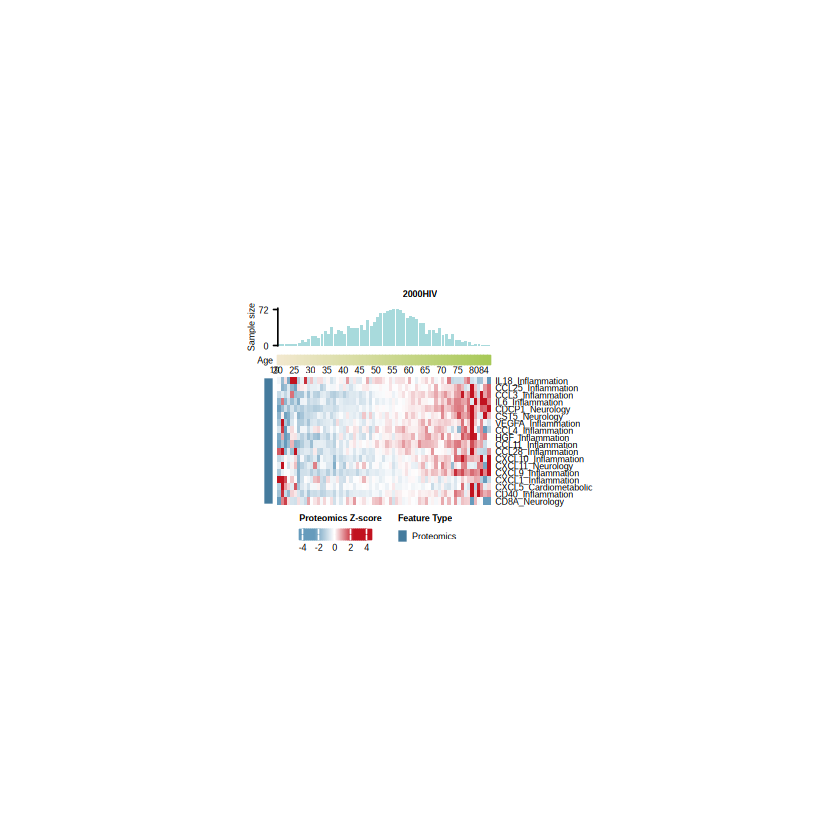

In [8]:
###nature style
# ========== Change 1: Add one line (Nature-style font, 6 pt) ==========
font_pt <- 5
row_height_mm <- 1.5 
heatmap_width_mm <- 45

# ========== Change 2: Add/update these in Heatmap() ==========
protein_heatmap <- Heatmap(
  protein_data_zscore,
  name = "Proteomics Z-score",
  height = unit(nrow(protein_data_zscore) * row_height_mm, "mm"),
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  row_names_gp = gpar(fontsize = font_pt),              # ADD
  column_names_gp = gpar(fontsize = font_pt),           # ADD
  col = protein_col_fun,
  row_dend_reorder = FALSE,
    width = unit(heatmap_width_mm, "mm"),
  top_annotation = HeatmapAnnotation(
    Age = anno_simple(age_sorted, col = age_col_fun, height = unit(2, "mm")),
    Age_Label = anno_text(age_labels, gp = gpar(fontsize = font_pt), rot = 0),  
    annotation_name_side = "left",
    annotation_name_gp = gpar(fontsize = font_pt)
  ),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#457b9d", col = "white"),
      width = unit(2, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE,
  heatmap_legend_param = list(                          # ADD this block
    title_gp = gpar(fontsize = font_pt, fontface = "bold"),
    labels_gp = gpar(fontsize = font_pt),
      direction = "horizontal",
    legend_width = unit(15, "mm"),          
    grid_height = unit(2, "mm")    
  )
)


# ========== Change 3: Feature Type legend font ==========
feature_type_legend_separate <- Legend(
  title = "Feature Type",
  title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  at = c("Proteomics"),
  legend_gp = gpar(fill = c("#457b9d")),
  labels_gp = gpar(fontsize = font_pt),
    grid_height = unit(2, "mm"),    
  grid_width = unit(2, "mm")    
)


# ========== Change 4: Sample count axis font ==========
sample_count_anno <- HeatmapAnnotation(
   `Sample size` = anno_barplot(
    sample_counts,
    gp = gpar(fill = "#a8dadc", col = NA, lwd = 0),
    height = unit(0.8, "cm"),
    axis_param = list(
      at = c(0, max(sample_counts)),
      labels = c("0", max(sample_counts)),
      gp = gpar(fontsize = font_pt)
    ),
    border = FALSE
  ),
  annotation_name_side = "left",
  annotation_name_gp = gpar(fontsize = font_pt)
)

heatmap_combined_separate <- sample_count_anno %v% protein_heatmap

# ========== Change 5: PDF size (Nature double-column) ==========
pdf("/vol/projects/yzhang/2000HIV/heatmap/output/heatmap_200hiv_spears_sig_shared_feature_nature_gender.pdf", width = 3.46, height = 3.5, onefile = FALSE)

draw(
  heatmap_combined_separate,
  column_title = "2000HIV",                    
  column_title_side = "top",
  column_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
   annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
  merge_legends = TRUE,
  legend_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  legend_labels_gp = gpar(fontsize = font_pt),
  legend_grid_height = unit(2, "mm"),
  legend_grid_width = unit(2, "mm"),
)

dev.off()

#29. **Display separate version on screen**
draw(
  heatmap_combined_separate,
  column_title = "2000HIV",                    
  column_title_side = "top",
  column_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
   annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
    merge_legends = TRUE
)

In [9]:
save.image("/vol/projects/yzhang/2000HIV/heatmap/output/heatmap_200hiv_spears_sig_feature_nature_gender.Rdata")